In [1]:
import segyio
import numpy as np
import matplotlib.pyplot as plt

filename = "TS/trace_maths_Rp_NEWAVO_IL6251.sgy"

with segyio.open(filename, "r") as f:
    f.mmap()

    data = segyio.tools.cube(f)  # (iline, xline, time)
    ilines = f.ilines
    xlines = f.xlines
    time   = f.samples

print("Cube shape:", data.shape)


Cube shape: (1, 351, 1001)


In [2]:
import segyio
import numpy as np
import matplotlib.pyplot as plt

input_sgy = "TS/trace_maths_Rp_NEWAVO_IL6251.sgy"

with segyio.open(input_sgy, "r", ignore_geometry=True) as f:
    ntrace = f.tracecount
    time = f.samples
    dt = segyio.tools.dt(f)/1000


In [3]:
import numpy as np

def s_transform_correct(trace, dt, fmin, fmax, df, gamma=1.0):
    trace = np.asarray(trace)
    nt = trace.size
    t = np.arange(nt) * dt

    freqs = np.arange(fmin, fmax + df, df)
    S = np.zeros((len(freqs), nt), dtype=complex)

    for i, f in enumerate(freqs):
        if f == 0:
            continue

        sigma = gamma / abs(f)

        for tau in range(nt):
            window = np.exp(
                -((t - t[tau])**2) / (2 * sigma**2)
            )
            S[i, tau] = np.sum(
                trace * window * np.exp(-1j * 2 * np.pi * f * t)
            )

    return np.abs(S), freqs, t


def wiggle_trace(ax, trace, t, scale=1.0, color='k'):
    trace = trace / np.max(np.abs(trace)) * scale
    ax.plot(trace, t, color=color, linewidth=1)


In [4]:
dt

2.0

In [5]:

with segyio.open(input_sgy, "r", ignore_geometry=True) as fin:
    tes  = fin.trace[100]

S, freqs_st, t = s_transform_correct(
            tes,
            dt=dt/1000,
            fmin=1,
            fmax=60,
            df=5,
            gamma=0.5)

In [6]:
tes

array([-1.3085055e-01, -3.3072609e-02,  5.4229423e-04, ...,
       -3.9358594e+02,  6.5530249e+02,  8.0814062e+02],
      shape=(1001,), dtype=float32)

In [7]:
S.shape

(13, 1001)

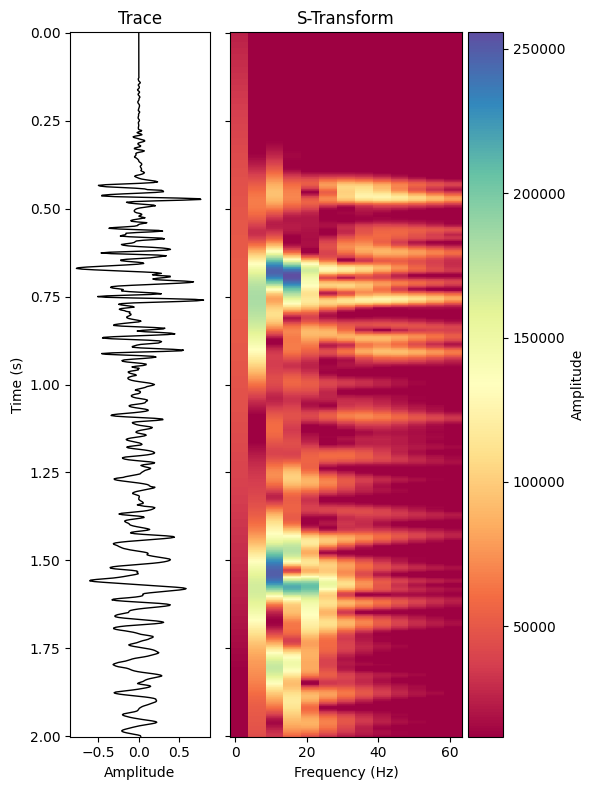

In [8]:
fig, (ax_wig, ax_tf) = plt.subplots(
    ncols=2,
    figsize=(6,8),
    sharey=True,
    gridspec_kw={'width_ratios': [1, 2]}
)

# --- Wiggle plot (kiri) ---
wiggle_trace(
    ax_wig,
    trace=tes,    # ganti dengan trace seismik kamu
    t=t,
    scale=0.8
)
ax_wig.set_xlabel("Amplitude")
ax_wig.set_ylabel("Time (s)")
ax_wig.invert_yaxis()
ax_wig.set_title("Trace")

# --- S-Transform (kanan) ---
im = ax_tf.pcolormesh(
    freqs_st,
    t,
    S.T,
    shading='auto',
    cmap='Spectral',
    vmin=np.percentile(S, 30),
    vmax=np.percentile(S, 100)
)
ax_tf.set_xlabel("Frequency (Hz)")
ax_tf.set_title("S-Transform")

# --- Colorbar ---
cbar = fig.colorbar(im, ax=ax_tf, pad=0.02)
cbar.set_label("Amplitude")

plt.tight_layout()
plt.show()


In [9]:
f_index = np.arange(5, 61, 5)   # Hz
nf = len(f_index)
nt = len(time)

In [35]:
import segyio

output_sgy = "Frequency_Gather_2.sgy"

spec = segyio.spec()
spec.format = 5
spec.samples = time
spec.tracecount = len(xlines) * nf   # HARUS integer > 0

with segyio.create(output_sgy, spec) as f:
    # PENTING: inisialisasi trace & header
    for i in range(spec.tracecount):
        f.trace[i] = np.zeros(len(time), dtype=np.float32)
        f.header[i][segyio.TraceField.TRACE_SEQUENCE_LINE] = i + 1


In [36]:
with segyio.open(input_sgy, "r", ignore_geometry=True) as fin, \
     segyio.open(output_sgy, "r+", ignore_geometry=True) as fout:

    itr_out = 0

    for itr in range(fin.tracecount):

        trace  = fin.trace[itr]
        hdr_in = fin.header[itr]

        inline = hdr_in[segyio.TraceField.INLINE_3D]
        xline  = hdr_in[segyio.TraceField.CROSSLINE_3D]

        S, freqs_st, _ = s_transform_correct(
            trace,
            dt=dt/1000,
            fmin=f_index[0],
            fmax=f_index[-1],
            df=f_index[1] - f_index[0],
            gamma=1.0
        )
        
        print(f"Trace {itr}")

        for i, fval in enumerate(freqs_st):

            fout.trace[itr_out] = S[i].astype(np.float32)

            hdr = fout.header[itr_out]
            hdr.update(hdr_in)

            hdr[segyio.TraceField.INLINE_3D]    = inline
            hdr[segyio.TraceField.CROSSLINE_3D] = xline
            hdr[segyio.TraceField.offset]       = int(fval * 1000)
            hdr[segyio.TraceField.TRACE_SEQUENCE_LINE] = itr_out + 1

            itr_out += 1


Trace 0
Trace 1
Trace 2
Trace 3
Trace 4
Trace 5
Trace 6
Trace 7
Trace 8
Trace 9
Trace 10
Trace 11
Trace 12
Trace 13
Trace 14
Trace 15
Trace 16
Trace 17
Trace 18
Trace 19
Trace 20
Trace 21
Trace 22
Trace 23
Trace 24
Trace 25
Trace 26
Trace 27
Trace 28
Trace 29
Trace 30
Trace 31
Trace 32
Trace 33
Trace 34
Trace 35
Trace 36
Trace 37
Trace 38
Trace 39
Trace 40
Trace 41
Trace 42
Trace 43
Trace 44
Trace 45
Trace 46
Trace 47
Trace 48
Trace 49
Trace 50
Trace 51
Trace 52
Trace 53
Trace 54
Trace 55
Trace 56
Trace 57
Trace 58
Trace 59
Trace 60
Trace 61
Trace 62
Trace 63
Trace 64
Trace 65
Trace 66
Trace 67
Trace 68
Trace 69
Trace 70
Trace 71
Trace 72
Trace 73
Trace 74
Trace 75
Trace 76
Trace 77
Trace 78
Trace 79
Trace 80
Trace 81
Trace 82
Trace 83
Trace 84
Trace 85
Trace 86
Trace 87
Trace 88
Trace 89
Trace 90
Trace 91
Trace 92
Trace 93
Trace 94
Trace 95
Trace 96
Trace 97
Trace 98
Trace 99
Trace 100
Trace 101
Trace 102
Trace 103
Trace 104
Trace 105
Trace 106
Trace 107
Trace 108
Trace 109
Trace 110


In [10]:

output_sgy = "Frequency_Gather.sgy"
with segyio.open(output_sgy, "r", ignore_geometry=True) as f:
    print("Tracecount :", f.tracecount)
    print("Samples    :", len(f.samples))
    print("Inline     :", f.header[15][segyio.TraceField.INLINE_3D])
    print("Xline      :", f.header[15][segyio.TraceField.CROSSLINE_3D])
    print("Offset(freq):", f.header[15][segyio.TraceField.offset])


Tracecount : 4212
Samples    : 1001
Inline     : 6251
Xline      : 2251
Offset(freq): 20000


In [11]:
with segyio.open(output_sgy, "r", ignore_geometry=True) as f:
    print("Tracecount :", f.tracecount)
    print("Samples    :", len(f.samples))
    print("Inline     :", f.header[0][segyio.TraceField.INLINE_3D])
    print("Xline      :", f.header[0][segyio.TraceField.CROSSLINE_3D])
    print("Offset(freq):", f.header[0][segyio.TraceField.offset])


Tracecount : 4212
Samples    : 1001
Inline     : 6251
Xline      : 2249
Offset(freq): 5000


In [12]:
import segyio
import numpy as np

xline_target = 2249   # ganti sesuai data

traces_ori = []
traces = []
offsets = []

with segyio.open(input_sgy, "r", ignore_geometry=True) as f:

    for itr in range(f.tracecount):
        hdr = f.header[itr]

        if hdr[segyio.TraceField.CROSSLINE_3D] == xline_target:
            traces_ori.append(f.trace[itr])


with segyio.open(output_sgy, "r", ignore_geometry=True) as f:

    time = f.samples

    for itr in range(f.tracecount):
        hdr = f.header[itr]

        if hdr[segyio.TraceField.CROSSLINE_3D] == xline_target:
            traces.append(f.trace[itr])
            offsets.append(hdr[segyio.TraceField.offset])


traces_ori  = np.array(traces_ori)
traces  = np.array(traces)
offsets = np.array(offsets) / 1000.0   # balik ke Hz


In [13]:
traces_ori.shape

(1, 1001)

In [14]:
traces.shape

(12, 1001)

In [15]:
idx = np.argsort(offsets)
offsets = offsets[idx]
traces  = traces[idx]

In [16]:
offsets

array([ 5., 10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60.])

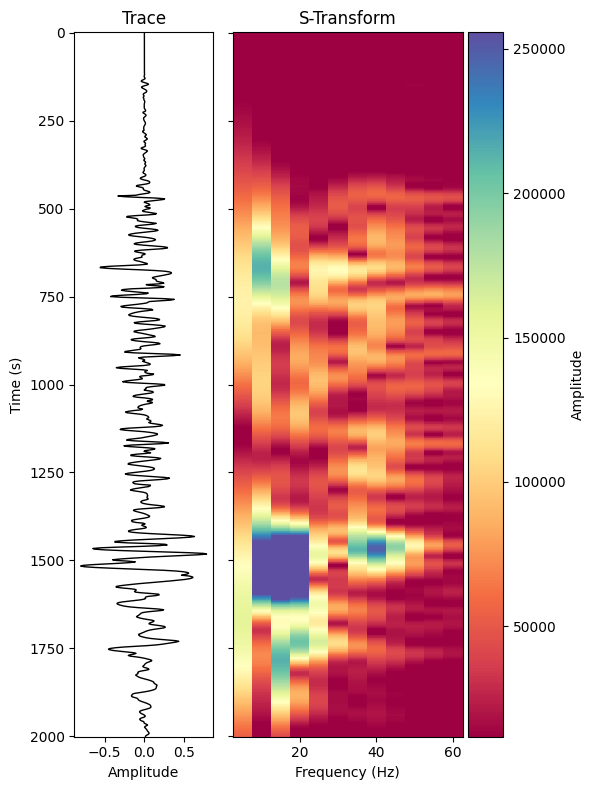

In [17]:
fig, (ax_wig, ax_tf) = plt.subplots(
    ncols=2,
    figsize=(6,8),
    sharey=True,
    gridspec_kw={'width_ratios': [1, 2]}
)

# --- Wiggle plot (kiri) ---
wiggle_trace(
    ax_wig,
    trace=traces_ori.T,    # ganti dengan trace seismik kamu
    t=time,
    scale=0.8
)
ax_wig.set_xlabel("Amplitude")
ax_wig.set_ylabel("Time (s)")
ax_wig.invert_yaxis()
ax_wig.set_title("Trace")

# --- S-Transform (kanan) ---
im = ax_tf.pcolormesh(
    offsets,
    time,
    traces.T,
    shading='auto',
    cmap='Spectral',
    vmin=np.percentile(S, 30),
    vmax=np.percentile(S, 100)
)
ax_tf.set_xlabel("Frequency (Hz)")
ax_tf.set_title("S-Transform")

# --- Colorbar ---
cbar = fig.colorbar(im, ax=ax_tf, pad=0.02)
cbar.set_label("Amplitude")

plt.tight_layout()
plt.show()


In [18]:
import segyio
import numpy as np

input_freq_sgy = "Frequency_Gather.sgy"
output_domfreq_sgy = "dominant_frequency.sgy"

with segyio.open(input_freq_sgy, "r", ignore_geometry=True) as f:

    time = f.samples
    nt = len(time)

    xlines = np.array([
        f.header[i][segyio.TraceField.CROSSLINE_3D]
        for i in range(f.tracecount)
    ])

    unique_xlines = np.unique(xlines)

    # mapping trace index per xline
    gather_map = {xl: [] for xl in unique_xlines}
    for i, xl in enumerate(xlines):
        gather_map[xl].append(i)

print("Jumlah gather:", len(unique_xlines))


Jumlah gather: 351


In [19]:
spec = segyio.spec()
spec.format     = 5
spec.samples    = time
spec.tracecount = len(unique_xlines)

with segyio.create(output_domfreq_sgy, spec) as f:
    for i in range(spec.tracecount):
        f.trace[i] = np.zeros(nt, dtype=np.float32)


In [20]:
from scipy.ndimage import gaussian_filter1d

with segyio.open(input_freq_sgy, "r", ignore_geometry=True) as fin, \
     segyio.open(output_domfreq_sgy, "r+", ignore_geometry=True) as fout:

    itr_out = 0

    for xline in unique_xlines:

        idxs = gather_map[xline]

        freqs  = []
        traces = []

        for itr in idxs:
            hdr = fin.header[itr]
            freqs.append(hdr[segyio.TraceField.offset] / 1000.0)
            traces.append(fin.trace[itr])

        freqs  = np.array(freqs)
        traces = np.array(traces)

        # sort frekuensi
        order  = np.argsort(freqs)
        freqs  = freqs[order]
        traces = traces[order]

        # =========================
        # DOMINANT FREQUENCY
        # =========================
        A = np.abs(traces)              # (nfreq, nt)
        idx_max = np.argmax(A, axis=0)  # per time
        f_dom = freqs[idx_max]

        # smoothing (opsional tapi disarankan)
        f_dom = gaussian_filter1d(f_dom, sigma=5)

        # =========================
        # TULIS TRACE OUTPUT
        # =========================
        fout.trace[itr_out] = f_dom.astype(np.float32)

        hdr_out = fout.header[itr_out]
        hdr_in  = fin.header[idxs[0]]

        hdr_out.update(hdr_in)
        hdr_out[segyio.TraceField.offset] = 0
        hdr_out[segyio.TraceField.CROSSLINE_3D] = xline
        hdr_out[segyio.TraceField.TRACE_SEQUENCE_LINE] = itr_out + 1

        itr_out += 1


In [21]:
with segyio.open(output_domfreq_sgy, "r", ignore_geometry=True) as f:
    print("Tracecount:", f.tracecount)
    print("Samples:", len(f.samples))
    print("Min/Max dominant freq:",
          np.min(f.trace[0]), np.max(f.trace[0]))


Tracecount: 351
Samples: 1001
Min/Max dominant freq: 5.0 48.030956


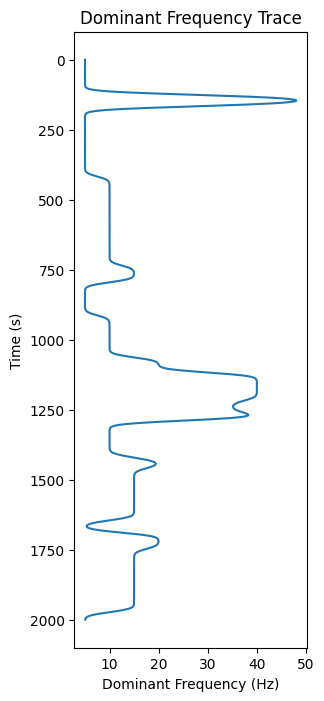

In [22]:
import matplotlib.pyplot as plt
import segyio

with segyio.open(output_domfreq_sgy, "r", ignore_geometry=True) as f:

    trace0 = f.trace[0].copy()
    time   = f.samples.copy()

plt.figure(figsize=(3,8))
plt.plot(trace0, time)
plt.gca().invert_yaxis()
plt.xlabel("Dominant Frequency (Hz)")
plt.ylabel("Time (s)")
plt.title("Dominant Frequency Trace")
plt.show()


In [23]:
import segyio
import numpy as np
import matplotlib.pyplot as plt

filename = "dominant_frequency.sgy"

with segyio.open(filename, "r") as f:
    f.mmap()

    data = segyio.tools.cube(f)  # (iline, xline, time)
    ilines = f.ilines
    xlines = f.xlines
    time   = f.samples

print("Cube shape:", data.shape)


Cube shape: (1, 351, 1001)


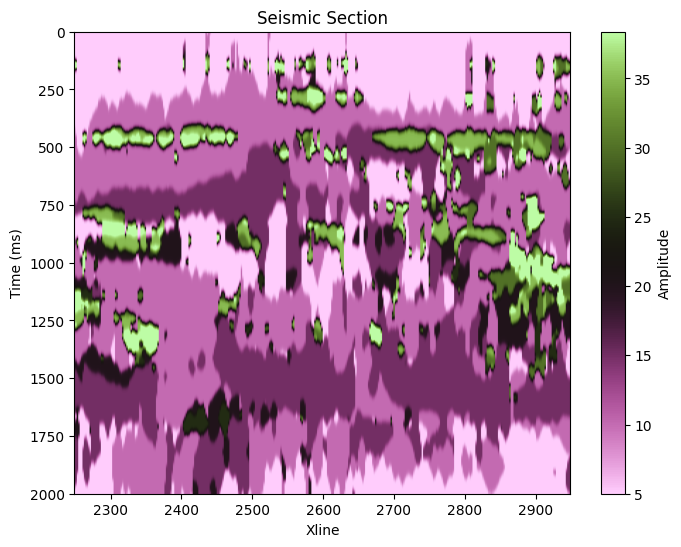

In [24]:
plt.figure(figsize=(8,6))
plt.imshow(
    data.T,
    aspect='auto',
    cmap='vanimo',
    vmin= np.percentile(data, 2),
    vmax= np.percentile(data, 98),
    extent=[xlines[0], xlines[-1], time[-1], time[0]]
)
plt.xlabel("Xline")
plt.ylabel("Time (ms)")
plt.title("Seismic Section")
plt.colorbar(label="Amplitude")
plt.show()

In [25]:
import segyio
import numpy as np

input_freq_sgy = "Frequency_Gather.sgy"
output_f80_sgy = "freq_drop80.sgy"

with segyio.open(input_freq_sgy, "r", ignore_geometry=True) as f:

    time = f.samples
    nt = len(time)

    xlines = np.array([
        f.header[i][segyio.TraceField.CROSSLINE_3D]
        for i in range(f.tracecount)
    ])

    unique_xlines = np.unique(xlines)

    gather_map = {xl: [] for xl in unique_xlines}
    for i, xl in enumerate(xlines):
        gather_map[xl].append(i)

print("Jumlah gather:", len(unique_xlines))


Jumlah gather: 351


In [26]:
spec = segyio.spec()
spec.format     = 5
spec.samples    = time
spec.tracecount = len(unique_xlines)

with segyio.create(output_f80_sgy, spec) as f:
    for i in range(spec.tracecount):
        f.trace[i] = np.zeros(nt, dtype=np.float32)


In [27]:
from scipy.ndimage import gaussian_filter1d

with segyio.open(input_freq_sgy, "r", ignore_geometry=True) as fin, \
     segyio.open(output_f80_sgy, "r+", ignore_geometry=True) as fout:

    itr_out = 0

    for xline in unique_xlines:

        idxs = gather_map[xline]

        freqs  = []
        traces = []

        for itr in idxs:
            hdr = fin.header[itr]
            freqs.append(hdr[segyio.TraceField.offset] / 1000.0)
            traces.append(fin.trace[itr])

        freqs  = np.array(freqs)
        traces = np.array(traces)

        # sort berdasarkan frekuensi
        order  = np.argsort(freqs)
        freqs  = freqs[order]
        traces = traces[order]

        A = np.abs(traces)   # (nfreq, nt)

        # =========================
        # DOMINANT FREQUENCY
        # =========================
        idx_dom = np.argmax(A, axis=0)
        f_dom   = freqs[idx_dom]
        A_dom   = A[idx_dom, np.arange(nt)]

        # =========================
        # 80% DROP FREQUENCY
        # =========================
        f_80 = np.zeros(nt)

        for it in range(nt):

            id0 = idx_dom[it]
            thr = 0.2 * A_dom[it]

            # cari frekuensi setelah dominant
            found = False
            for jf in range(id0 + 1, len(freqs)):
                if A[jf, it] <= thr:
                    f_80[it] = freqs[jf]
                    found = True
                    break

            # fallback kalau tidak ketemu
            if not found:
                f_80[it] = freqs[-1]

        # smoothing (disarankan)
        f_80 = gaussian_filter1d(f_80, sigma=5)

        # =========================
        # TULIS TRACE
        # =========================
        fout.trace[itr_out] = f_80.astype(np.float32)

        hdr_out = fout.header[itr_out]
        hdr_in  = fin.header[idxs[0]]

        hdr_out.update(hdr_in)
        hdr_out[segyio.TraceField.offset] = 0
        hdr_out[segyio.TraceField.CROSSLINE_3D] = xline
        hdr_out[segyio.TraceField.TRACE_SEQUENCE_LINE] = itr_out + 1

        itr_out += 1


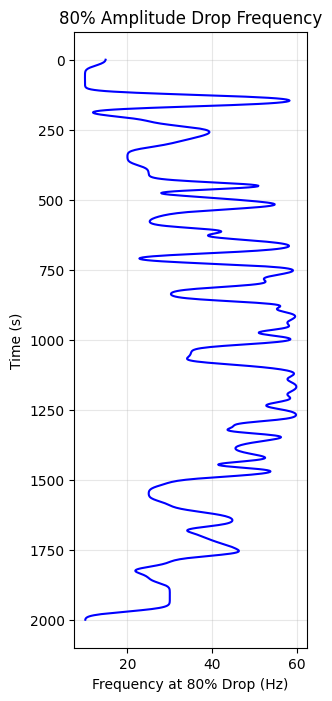

In [28]:
import matplotlib.pyplot as plt


with segyio.open(output_f80_sgy, "r", ignore_geometry=True) as f:
    trace0 = f.trace[0].copy()
    time   = f.samples.copy()

plt.figure(figsize=(3,8))
plt.plot(trace0, time, 'b')
plt.gca().invert_yaxis()
plt.xlabel("Frequency at 80% Drop (Hz)")
plt.ylabel("Time (s)")
plt.title("80% Amplitude Drop Frequency")
plt.grid(alpha=0.3)
plt.show()


Cube shape: (1, 351, 1001)


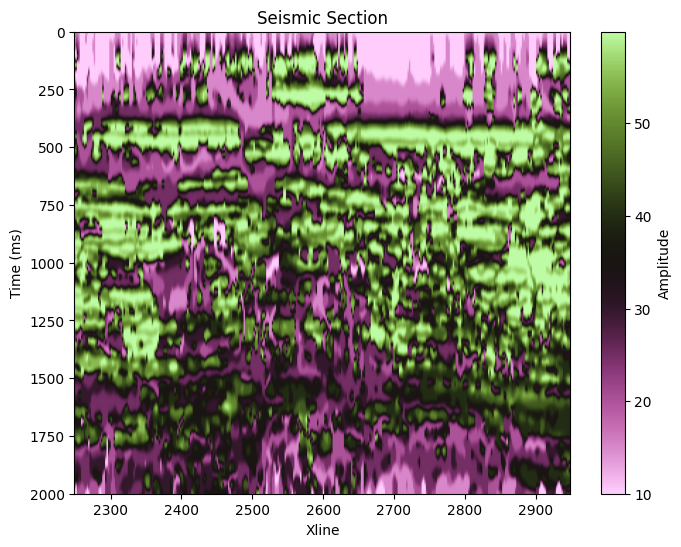

In [29]:
import segyio
import numpy as np
import matplotlib.pyplot as plt

filename = "freq_drop80.sgy"

with segyio.open(filename, "r") as f:
    f.mmap()

    data = segyio.tools.cube(f)  # (iline, xline, time)
    ilines = f.ilines
    xlines = f.xlines
    time   = f.samples

print("Cube shape:", data.shape)

plt.figure(figsize=(8,6))
plt.imshow(
    data.T,
    aspect='auto',
    cmap='vanimo',
    vmin= np.percentile(data, 2),
    vmax= np.percentile(data, 98),
    extent=[xlines[0], xlines[-1], time[-1], time[0]]
)
plt.xlabel("Xline")
plt.ylabel("Time (ms)")
plt.title("Seismic Section")
plt.colorbar(label="Amplitude")
plt.show()

In [30]:
import segyio
import numpy as np

input_freq_sgy = "Frequency_Gather.sgy"
output_grad_sgy = "spectral_gradient.sgy"

with segyio.open(input_freq_sgy, "r", ignore_geometry=True) as f:

    time = f.samples
    nt = len(time)

    xlines = np.array([
        f.header[i][segyio.TraceField.CROSSLINE_3D]
        for i in range(f.tracecount)
    ])

    unique_xlines = np.unique(xlines)

    gather_map = {xl: [] for xl in unique_xlines}
    for i, xl in enumerate(xlines):
        gather_map[xl].append(i)


In [31]:
spec = segyio.spec()
spec.format     = 5
spec.samples    = time
spec.tracecount = len(unique_xlines)

with segyio.create(output_grad_sgy, spec) as f:
    for i in range(spec.tracecount):
        f.trace[i] = np.zeros(nt, dtype=np.float32)


In [32]:
from scipy.ndimage import gaussian_filter1d

with segyio.open(input_freq_sgy, "r", ignore_geometry=True) as fin, \
     segyio.open(output_grad_sgy, "r+", ignore_geometry=True) as fout:

    itr_out = 0

    for xline in unique_xlines:

        idxs = gather_map[xline]

        freqs  = []
        traces = []

        for itr in idxs:
            hdr = fin.header[itr]
            freqs.append(hdr[segyio.TraceField.offset] / 1000.0)  # Hz
            traces.append(fin.trace[itr])

        freqs  = np.array(freqs)
        traces = np.array(traces)

        # sort frekuensi
        order  = np.argsort(freqs)
        freqs  = freqs[order]
        traces = traces[order]

        A = np.abs(traces)   # (nfreq, nt)

        # =============================
        # DOMINANT FREQUENCY
        # =============================
        idx_dom = np.argmax(A, axis=0)
        f_dom   = freqs[idx_dom]
        A_dom   = A[idx_dom, np.arange(nt)]

        # =============================
        # 80% DROP FREQUENCY
        # =============================
        f_80 = np.zeros(nt)

        for it in range(nt):
            thr = 0.2 * A_dom[it]
            id0 = idx_dom[it]

            found = False
            for jf in range(id0 + 1, len(freqs)):
                if A[jf, it] <= thr:
                    f_80[it] = freqs[jf]
                    found = True
                    break

            if not found:
                f_80[it] = freqs[-1]

        # =============================
        # SPECTRAL GRADIENT
        # =============================
        df = f_80 - f_dom
        df[df <= 0] = np.nan   # hindari division error

        grad = 0.8 * A_dom / df

        # optional smoothing
        grad = gaussian_filter1d(grad, sigma=5)
        grad = np.nan_to_num(grad)

        # =============================
        # WRITE TRACE
        # =============================
        fout.trace[itr_out] = grad.astype(np.float32)

        hdr_out = fout.header[itr_out]
        hdr_in  = fin.header[idxs[0]]

        hdr_out.update(hdr_in)
        hdr_out[segyio.TraceField.offset] = 0
        hdr_out[segyio.TraceField.CROSSLINE_3D] = xline
        hdr_out[segyio.TraceField.TRACE_SEQUENCE_LINE] = itr_out + 1

        itr_out += 1


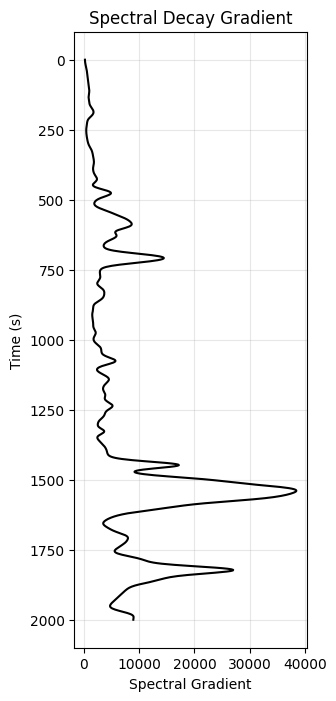

In [33]:
import matplotlib.pyplot as plt

with segyio.open(output_grad_sgy, "r", ignore_geometry=True) as f:
    grad0 = f.trace[0].copy()
    time  = f.samples.copy()

plt.figure(figsize=(3,8))
plt.plot(grad0, time, 'k')
plt.gca().invert_yaxis()
plt.xlabel("Spectral Gradient")
plt.ylabel("Time (s)")
plt.title("Spectral Decay Gradient")
plt.grid(alpha=0.3)
plt.show()


Cube shape: (1, 351, 1001)


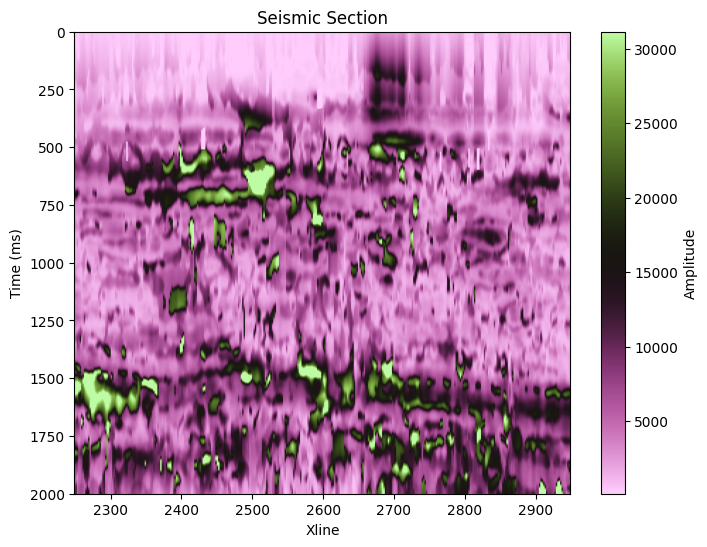

In [34]:
import segyio
import numpy as np
import matplotlib.pyplot as plt

filename = "spectral_gradient.sgy"

with segyio.open(filename, "r") as f:
    f.mmap()

    data = segyio.tools.cube(f)  # (iline, xline, time)
    ilines = f.ilines
    xlines = f.xlines
    time   = f.samples

print("Cube shape:", data.shape)

plt.figure(figsize=(8,6))
plt.imshow(
    data.T,
    aspect='auto',
    cmap='vanimo',
    vmin= np.percentile(data, 1),
    vmax= np.percentile(data, 99),
    extent=[xlines[0], xlines[-1], time[-1], time[0]]
)
plt.xlabel("Xline")
plt.ylabel("Time (ms)")
plt.title("Seismic Section")
plt.colorbar(label="Amplitude")
plt.show()